C:\Users\Kani\AppData\Local\Temp\ipykernel_13288\3288437644.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby('bin')['label'].count()
C:\Users\Kani\AppData\Local\Temp\ipykernel_13288\3288437644.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_positives = df.groupby('bin')['label'].sum()


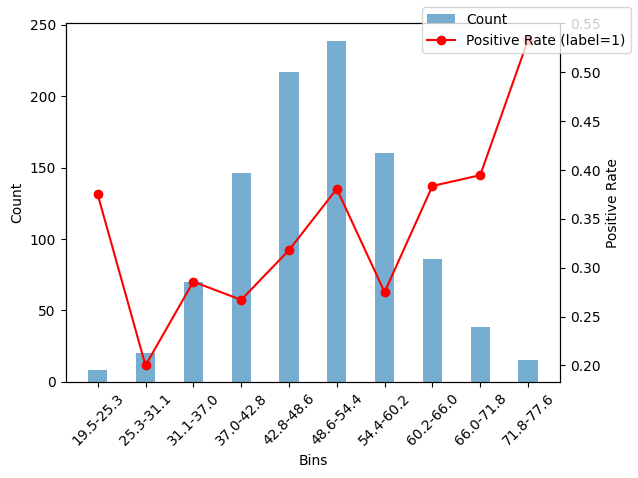

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# サンプルデータの作成
np.random.seed(0)
df = pd.DataFrame({
    'value': np.random.normal(loc=50, scale=10, size=1000),
    'label': np.random.choice([0, 1], size=1000, p=[0.7, 0.3])
})

# ビンの設定
bins = np.histogram_bin_edges(df['value'], bins=10)

# 各ビンにおける全体の件数とlabel=1の件数を集計
df['bin'] = pd.cut(df['value'], bins=bins)
bin_counts = df.groupby('bin')['label'].count()
bin_positives = df.groupby('bin')['label'].sum()
bin_positive_rate = bin_positives / bin_counts

# ヒストグラムと割合の棒グラフを重ねて表示
fig, ax1 = plt.subplots()

# ヒストグラム（全体の件数）
ax1.bar(range(len(bin_counts)), bin_counts, width=0.4, label='Count', align='center', alpha=0.6)
ax1.set_ylabel('Count')
ax1.set_xlabel('Bins')
ax1.set_xticks(range(len(bin_counts)))
ax1.set_xticklabels([f'{interval.left:.1f}-{interval.right:.1f}' for interval in bin_counts.index], rotation=45)

# 割合の折れ線グラフ
ax2 = ax1.twinx()
ax2.plot(range(len(bin_positive_rate)), bin_positive_rate, color='red', marker='o', label='Positive Rate (label=1)')
ax2.set_ylabel('Positive Rate')

# 凡例とレイアウト調整
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()


(1000, 2)
       value  label
0  67.640523      1
1  54.001572      1
2  59.787380      1
3  72.408932      1
4  68.675580      1

 (1000, 3)
       value  label               bin
0  67.640523      1  (65.983, 71.788]
1  54.001572      1  (48.566, 54.372]
2  59.787380      1  (54.372, 60.177]
3  72.408932      1  (71.788, 77.594]
4  68.675580      1  (65.983, 71.788]

 label               0   1
bin                      
(19.539, 25.344]    5   3
(25.344, 31.15]    16   4
(31.15, 36.955]    50  20
(36.955, 42.761]  107  39
(42.761, 48.566]  148  69
(48.566, 54.372]  148  91
(54.372, 60.177]  116  44
(60.177, 65.983]   53  33
(65.983, 71.788]   23  15
(71.788, 77.594]    7   8
x=[0 1 2 3 4 5 6 7 8 9]


C:\Users\Kani\AppData\Local\Temp\ipykernel_13288\199371402.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_label_counts = df.groupby(['bin', 'label']).size().unstack(fill_value=0)


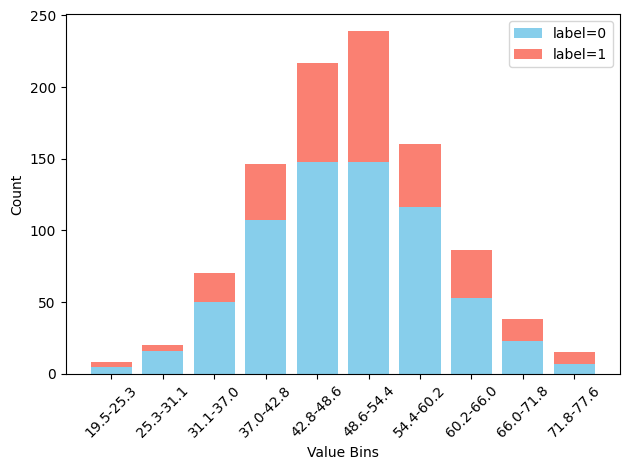

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# サンプルデータ
np.random.seed(0)
df = pd.DataFrame({
    'value': np.random.normal(loc=50, scale=10, size=1000),
    'label': np.random.choice([0, 1], size=1000, p=[0.7, 0.3])
})
print(df.shape)
print(df.head(5))

# ビン分け
bins = np.histogram_bin_edges(df['value'], bins=10)
df['bin'] = pd.cut(df['value'], bins=bins)
print('\n',df.shape)
print(df.head(5))

# 各ビンごとのlabel=1とlabel=0の数を集計
bin_label_counts = df.groupby(['bin', 'label']).size().unstack(fill_value=0)
print('\n',bin_label_counts)

# 棒グラフの描画
x = np.arange(len(bin_label_counts))
print(f'x={x}')
width = 0.8

fig, ax = plt.subplots()
ax.bar(x, bin_label_counts[0], width, label='label=0', color='skyblue')
ax.bar(x, bin_label_counts[1], width, bottom=bin_label_counts[0], label='label=1', color='salmon')

# 軸とラベル
ax.set_xticks(x)
ax.set_xticklabels([f'{interval.left:.1f}-{interval.right:.1f}' for interval in bin_label_counts.index], rotation=45)
ax.set_xlabel('Value Bins')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()
